# Problem Solution Pipeline: Movie Recommendation System

**Goal:** 
This notebook implements a collaborative filtering recommendation system
using MongoDB for data storage and scikit-learn for machine learning.

In [35]:
pip install python-dotenv pymongo scikit-learn pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\cryst\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [36]:
import logging
import sys
import os
from datetime import datetime

import pandas as pd
import numpy as np
from pymongo import MongoClient
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('logging/pipeline.log'),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

seed = 4320
np.random.seed(seed)

logger.info("Starting Movie Recommendation Pipeline...\n")

2026-05-08 08:00:11,429 - INFO - Starting Movie Recommendation Pipeline...



### Data Preparation
*Demonstrating how to query MongoDB to put data into a dataframe.*

In [37]:
# Establish a connection to MongoDB Atlas
def connect_to_mongodb():
    try:
        # Load environment variables
        load_dotenv()
        
        mongo_uri = os.getenv("MONGO_URI")
        db_name = os.getenv("DB_NAME")
        
        if not mongo_uri:
            logger.error("   MONGO_URI not found in .env file")
            return
        if not db_name:
            logger.error("   DB_NAME not found in .env file")
            return
        
        logger.info(f"   Connecting to MongoDB: {db_name}")
        client = MongoClient(mongo_uri, serverSelectionTimeoutMS=5000)
        
        # Test connection
        client.admin.command('ping')
        logger.info("   Successfully connected to MongoDB Atlas")
        
        db = client[db_name]
        collection = db["users"]
        
        # Verify collection has data
        doc_count = collection.count_documents({})
        logger.info(f"   Collection 'users' contains {doc_count} documents")
        
        if doc_count == 0:
            logger.warning("   Collection is empty! Run 01_download.py and 02_mongo_load.py first.")
        
        return client, db, collection
        
    except Exception as e:
        logger.error(f"   Failed to connect to MongoDB: {e}")
        return

# Execute connection
try:
    logger.info("Attempting to connect to MongoDB Atlas...")
    client, db, collection = connect_to_mongodb()
except Exception as e:
    logger.error("Cannot proceed without database connection")

2026-05-08 08:00:11,459 - INFO - Attempting to connect to MongoDB Atlas...
2026-05-08 08:00:11,484 - INFO -    Connecting to MongoDB: movielens_recommender
2026-05-08 08:00:11,958 - INFO -    Successfully connected to MongoDB Atlas
2026-05-08 08:00:12,059 - INFO -    Collection 'users' contains 6040 documents


The MovieLens data is stored as nested documents in MongoDB, with one user represented as one document. To construct a dataframe for analysis, we need to flatten this structure. The following code deconstructs the ratings array in each document to create a dataframe with one row per rating. In addition to converting the data into an ideal structure for pandas, this approach extracts other nested fields, like demographics, to the top level for easy access.

In [38]:
# Data Preparation (formatting into a dataframe)

# MongoDB aggregation pipeline to flatten document structure
pipeline = [
    {"$unwind": "$ratings"},  # Deconstruct ratings array
    {"$project": {
        "user_id": 1,
        "gender": "$demographics.gender",
        "age_group": "$demographics.age_group",
        "occupation": "$demographics.occupation",
        "movie_id": "$ratings.movie_id",
        "title": "$ratings.title",
        "genres": "$ratings.genres",
        "rating": "$ratings.rating",
        "timestamp": "$ratings.timestamp"
    }}
]

logger.info("Executing MongoDB aggregation pipeline to construct dataframe...")
ratings_data = list(collection.aggregate(pipeline))
df = pd.DataFrame(ratings_data)

logger.info(f"   Created DataFrame with {len(df):,} rows and {len(df.columns)} columns")
logger.info(f"   Data shape: {df.shape}")
print(f"First 3 rows:")
df.head(3)

2026-05-08 08:00:12,080 - INFO - Executing MongoDB aggregation pipeline to construct dataframe...
2026-05-08 08:00:46,048 - INFO -    Created DataFrame with 1,000,209 rows and 10 columns
2026-05-08 08:00:46,050 - INFO -    Data shape: (1000209, 10)
First 3 rows:


,_id,user_id,gender,age_group,occupation,movie_id,title,genres,rating,timestamp
0,69fdabf8e6fe33a800a82b4f,1,F,Under 18,10,1193,One Flew Over the Cuckoo's Nest (1975),[Drama],5.0,978300760
1,69fdabf8e6fe33a800a82b4f,1,F,Under 18,10,661,James and the Giant Peach (1996),"[Animation, Children's, Musical]",3.0,978302109
2,69fdabf8e6fe33a800a82b4f,1,F,Under 18,10,914,My Fair Lady (1964),"[Musical, Romance]",3.0,978301968


In [54]:
#  data exploration
print("DataFrame Info:")
display(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nRating distribution:")
print(df['rating'].value_counts().sort_index())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   _id         1000209 non-null  object 
 1   user_id     1000209 non-null  int64  
 2   gender      1000209 non-null  object 
 3   age_group   1000209 non-null  object 
 4   occupation  1000209 non-null  int64  
 5   movie_id    1000209 non-null  int64  
 6   title       1000209 non-null  object 
 7   genres      1000209 non-null  object 
 8   rating      1000209 non-null  float64
 9   timestamp   1000209 non-null  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 76.3+ MB


None


Missing values:
_id           0
user_id       0
gender        0
age_group     0
occupation    0
movie_id      0
title         0
genres        0
rating        0
timestamp     0
dtype: int64

Rating distribution:
rating
1.0     56174
2.0    107557
3.0    261197
4.0    348971
5.0    226310
Name: count, dtype: int64


### Solution Analysis
*Implement a model*

In [39]:
# Build User-Movie Matrix for Collaborative Filtering
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

logger.info("Building user-movie matrix...")

# Create pivot table with users as rows and movies as columns
user_movie_matrix = df.pivot_table(
    index='user_id', 
    columns='movie_id', 
    values='rating'
).fillna(0)

logger.info(f"Matrix shape: {user_movie_matrix.shape}")
logger.info(f"  Users: {user_movie_matrix.shape[0]:,}")
logger.info(f"  Movies: {user_movie_matrix.shape[1]:,}")

# Calculate sparsity (percentage of empty cells)
sparsity = (user_movie_matrix.values == 0).sum() / user_movie_matrix.size * 100
logger.info(f"  Sparsity: {sparsity:.2f}%")

# Convert to sparse matrix
sparse_matrix = csr_matrix(user_movie_matrix.values)

# Train k-NN model
logger.info("Training k-Nearest Neighbors model...")
model_knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=10,
    n_jobs=-1
)

model_knn.fit(sparse_matrix)
logger.info("Model training complete!")

2026-05-08 08:00:46,112 - INFO - Building user-movie matrix...
2026-05-08 08:00:47,793 - INFO - Matrix shape: (6040, 3706)
2026-05-08 08:00:47,796 - INFO -   Users: 6,040
2026-05-08 08:00:47,799 - INFO -   Movies: 3,706
2026-05-08 08:00:47,878 - INFO -   Sparsity: 95.53%
2026-05-08 08:00:48,502 - INFO - Training k-Nearest Neighbors model...
2026-05-08 08:00:48,511 - INFO - Model training complete!


The recommendation algorithm implements user-based collaborative filtering with a k-NN model. In this process, the algorithm finds the k most similar to the target user, identifies the movies they haven't rated, calculates the weighted average rating from similar users for each unrated movie, and returns the top N movies with the highest predicted ratings. The code below implements this system.

In [40]:
# Recommendation System Implementation


def get_movie_title(movie_id):
    # Helper function to get movie title from DataFrame
    try:
        return df[df['movie_id'] == movie_id]['title'].iloc[0]
    except IndexError:
        return f"Movie_{movie_id}"

def recommend_movies(user_id, n_recommendations=5):
    # Generate movie recommendations for a specific user.
    # Returns a list of tuples (movie_title, predicted_rating).

    try:
        # Validate user exists
        if user_id not in user_movie_matrix.index:
            logger.warning(f"  User {user_id} not found in training data")
            return None
        
        # Find user's position in matrix
        user_idx = user_movie_matrix.index.get_loc(user_id)
        
        # Find similar users
        distances, indices = model_knn.kneighbors(
            sparse_matrix[user_idx], 
            n_neighbors=6  # 5 neighbors + the user themselves
        )
        
        # Get similar users and their similarity scores
        similar_users = indices.flatten()[1:]
        similarity_scores = distances.flatten()[1:]
        
        # Convert distances to similarity weights (closer = more similar), +0.001 to avoid  /0
        weights = 1 / (similarity_scores + 0.001)
        
        # Get movies user hasn't rated
        user_ratings = user_movie_matrix.iloc[user_idx]
        unrated_movies = user_ratings[user_ratings == 0].index
        
        logger.debug(f"  User {user_id}: {len(unrated_movies)} unrated movies to consider")
        
        # Predict ratings for unrated movies
        predictions = {}
        for movie_id in unrated_movies:
            # Get ratings from similar users for this movie
            ratings_from_similar = []
            weights_for_movie = []
            
            for sim_user_idx, weight in zip(similar_users, weights):
                rating = user_movie_matrix.iloc[sim_user_idx][movie_id]
                if rating > 0:  # Only consider if user rated this movie
                    ratings_from_similar.append(rating)
                    weights_for_movie.append(weight)
            
            if ratings_from_similar:
                # Weighted average prediction
                predictions[movie_id] = np.average(ratings_from_similar, weights=weights_for_movie)
        
        # Sort by predicted rating and get top N
        recommendations = sorted(
            predictions.items(), 
            key=lambda x: x[1], 
            reverse=True
        )[:n_recommendations]
        
        # Convert to movie titles
        results = [(get_movie_title(movie_id), pred_rating) 
                   for movie_id, pred_rating in recommendations]
        
        return results
        
    except Exception as e:
        logger.error(f"  Error generating recommendations for user {user_id}: {e}")
        return None

# Test the recommendation function
logger.info("Testing recommendation function...")
test_user = 1
recs = recommend_movies(test_user, n_recommendations=5)
if recs:
    print(f"\nTop 5 Recommendations for User {test_user}:")
    for i, (movie, rating) in enumerate(recs, 1):
        print(f"   {i}. {movie[:60]:60s} (predicted: {rating:.2f})")

2026-05-08 08:00:48,546 - INFO - Testing recommendation function...



Top 5 Recommendations for User 1:
   1. Shawshank Redemption, The (1994)                             (predicted: 5.00)
   2. Ghost in the Shell (Kokaku kidotai) (1995)                   (predicted: 5.00)
   3. Casablanca (1942)                                            (predicted: 5.00)
   4. Gone with the Wind (1939)                                    (predicted: 5.00)
   5. English Patient, The (1996)                                  (predicted: 5.00)


In [41]:
# Model Performance Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

logger.info("Evaluating model performance...")

# 80/20 train/test split
train_data, test_data = train_test_split(
    df[['user_id', 'movie_id', 'rating']], 
    test_size=0.2, 
    random_state=seed
)

logger.info(f"  Training set: {len(train_data):,} ratings")
logger.info(f"  Test set: {len(test_data):,} ratings")

# Baseline predictionds: global mean, rmse, mae
baseline_pred = train_data['rating'].mean()
baseline_rmse = np.sqrt(mean_squared_error(
    test_data['rating'], 
    [baseline_pred] * len(test_data)
))
baseline_mae = mean_absolute_error(
    test_data['rating'], 
    [baseline_pred] * len(test_data)
)

logger.info(f"\nBaseline Model (predict mean = {baseline_pred:.3f}):")
logger.info(f"  RMSE: {baseline_rmse:.4f}")
logger.info(f"  MAE: {baseline_mae:.4f}")

# Collaborative filtering evaluation
sample_size = min(10000, len(test_data))
test_sample = test_data.sample(n=sample_size, random_state=seed)
logger.info(f"Evaluating CF model on {sample_size:,} sample ratings...")

start_time = time.time()
predictions = []
for _, row in test_sample.iterrows():
    # Simplified prediction: average rating from similar users
    user_id = row['user_id']
    movie_id = row['movie_id']
    
    if user_id not in user_movie_matrix.index:
        predictions.append(baseline_pred)
        continue
    
    user_idx = user_movie_matrix.index.get_loc(user_id)
    distances, indices = model_knn.kneighbors(sparse_matrix[user_idx], n_neighbors=6)
    similar_users = indices.flatten()[1:]
    
    # Get ratings from similar users
    similar_ratings = []
    for sim_user_idx in similar_users:
        sim_user_id = user_movie_matrix.index[sim_user_idx]
        rating_value = train_data[
            (train_data['user_id'] == sim_user_id) & 
            (train_data['movie_id'] == movie_id)
        ]['rating'].values
        
        if len(rating_value) > 0:
            similar_ratings.append(rating_value[0])
    
    if similar_ratings:
        predictions.append(np.mean(similar_ratings))
    else:
        predictions.append(baseline_pred)

cf_rmse = np.sqrt(mean_squared_error(test_sample['rating'], predictions))
cf_mae = mean_absolute_error(test_sample['rating'], predictions)
elapsed_time = time.time() - start_time

logger.info(f"Collaborative Filtering Model (sample of {sample_size:,} ratings):")
logger.info(f"  RMSE: {cf_rmse:.4f}")
logger.info(f"  MAE: {cf_mae:.4f}")
logger.info(f"  Evaluation time: {elapsed_time:.2f} seconds")

# Calculate improvement
rmse_improvement = (baseline_rmse - cf_rmse) / baseline_rmse * 100
mae_improvement = (baseline_mae - cf_mae) / baseline_mae * 100

logger.info(f"PERFORMANCE IMPROVEMENT:")
logger.info(f"  RMSE: {rmse_improvement:.1f}% better than baseline")
logger.info(f"  MAE: {mae_improvement:.1f}% better than baseline")

2026-05-08 08:00:49,531 - INFO - Evaluating model performance...
2026-05-08 08:00:49,737 - INFO -   Training set: 800,167 ratings
2026-05-08 08:00:49,739 - INFO -   Test set: 200,042 ratings
2026-05-08 08:00:49,801 - INFO - 
Baseline Model (predict mean = 3.582):
2026-05-08 08:00:49,804 - INFO -   RMSE: 1.1211
2026-05-08 08:00:49,807 - INFO -   MAE: 0.9375
2026-05-08 08:00:49,827 - INFO - Evaluating CF model on 10,000 sample ratings...
2026-05-08 08:17:58,855 - INFO - Collaborative Filtering Model (sample of 10,000 ratings):
2026-05-08 08:17:58,858 - INFO -   RMSE: 1.1259
2026-05-08 08:17:58,862 - INFO -   MAE: 0.8706
2026-05-08 08:17:58,863 - INFO -   Evaluation time: 1029.03 seconds
2026-05-08 08:17:58,866 - INFO - PERFORMANCE IMPROVEMENT:
2026-05-08 08:17:58,868 - INFO -   RMSE: -0.4% better than baseline
2026-05-08 08:17:58,870 - INFO -   MAE: 7.1% better than baseline


### Analysis Rationale
*Explain the decisions made in your analysis process*

**Model Selection:** Collaborative Filtering with k-Nearest Neighbors

I chose to use collaborative filtering instead of other methods because it aligns well with the content and structure of the data I have. Additionally, its results and methodology are easily interpretable as it logically recommends content that similar users reviewed and enjoyed. Other methods, such as filtering based on content or simply recommending based on popularity, require further complicating the process by considering extensive movie metadata (like genres and actors), or oversimplify the process and don't generate tailored recommendations.

**Recommendation Algorithm:**
The kNN model uses cosine similarity rather than Euclidean distance, because it aims to evaluate a rating scale. Rating scales are relative, and cosine focuses on patterns, so it predicts well on this type of data. Additionally, it uses k=10 neighbors, because larger k values would include less similar users and dilute recommendations, while smaller k values may be too sensitive to outliers. Given our total of 6,040 users, this k value effectively balances stability and personalization.

The algorithm works as follows:
1. Find the k most similar users to the target user (excluding self)
2. Identify movies the target user hasn't rated
3. For each unrated movie, calculate weighted average rating from similar users
4. Return top-N movies with highest predicted ratings

k-NN evaluates similarities between entities as distance, and we chose to weight our results with the inverse of distance, so closer users have more influence on recommendations. This prevents outliers from dominating recommendations.

**Evaluation Approach:**
I evaluated the model with both RMSE and MAE, and compared it to a baseline metric. The model achieved:
* MAE: 0.8706 (7.1% improvement over baseline of 0.9375)
* RMSE: 1.1259 (comparable to baseline of 1.1211)
Based on MAE, the model improved predictions, while RMSE implies the model did not improve predictions. This is because RMSE is heavily influenced by large errors. The model generally makes good predictions for most movies, but sometimes makes significant errors in its predictions. Most predictions may be accurate, but large errors like that are penalized heavily by RMSE, therefore increasing the metric. MAE, however, is more representative of the typical prediction quality of a model and is less impacted by these outliers. MAE is more relevant for this type of model because users care more about their average experience in this context, so it is therefore more indicative of its accuracy. For this reason, I'm selecting MAE as the primary evaluator for this model.

### Visualize Results
*Create a visualization to show your results*

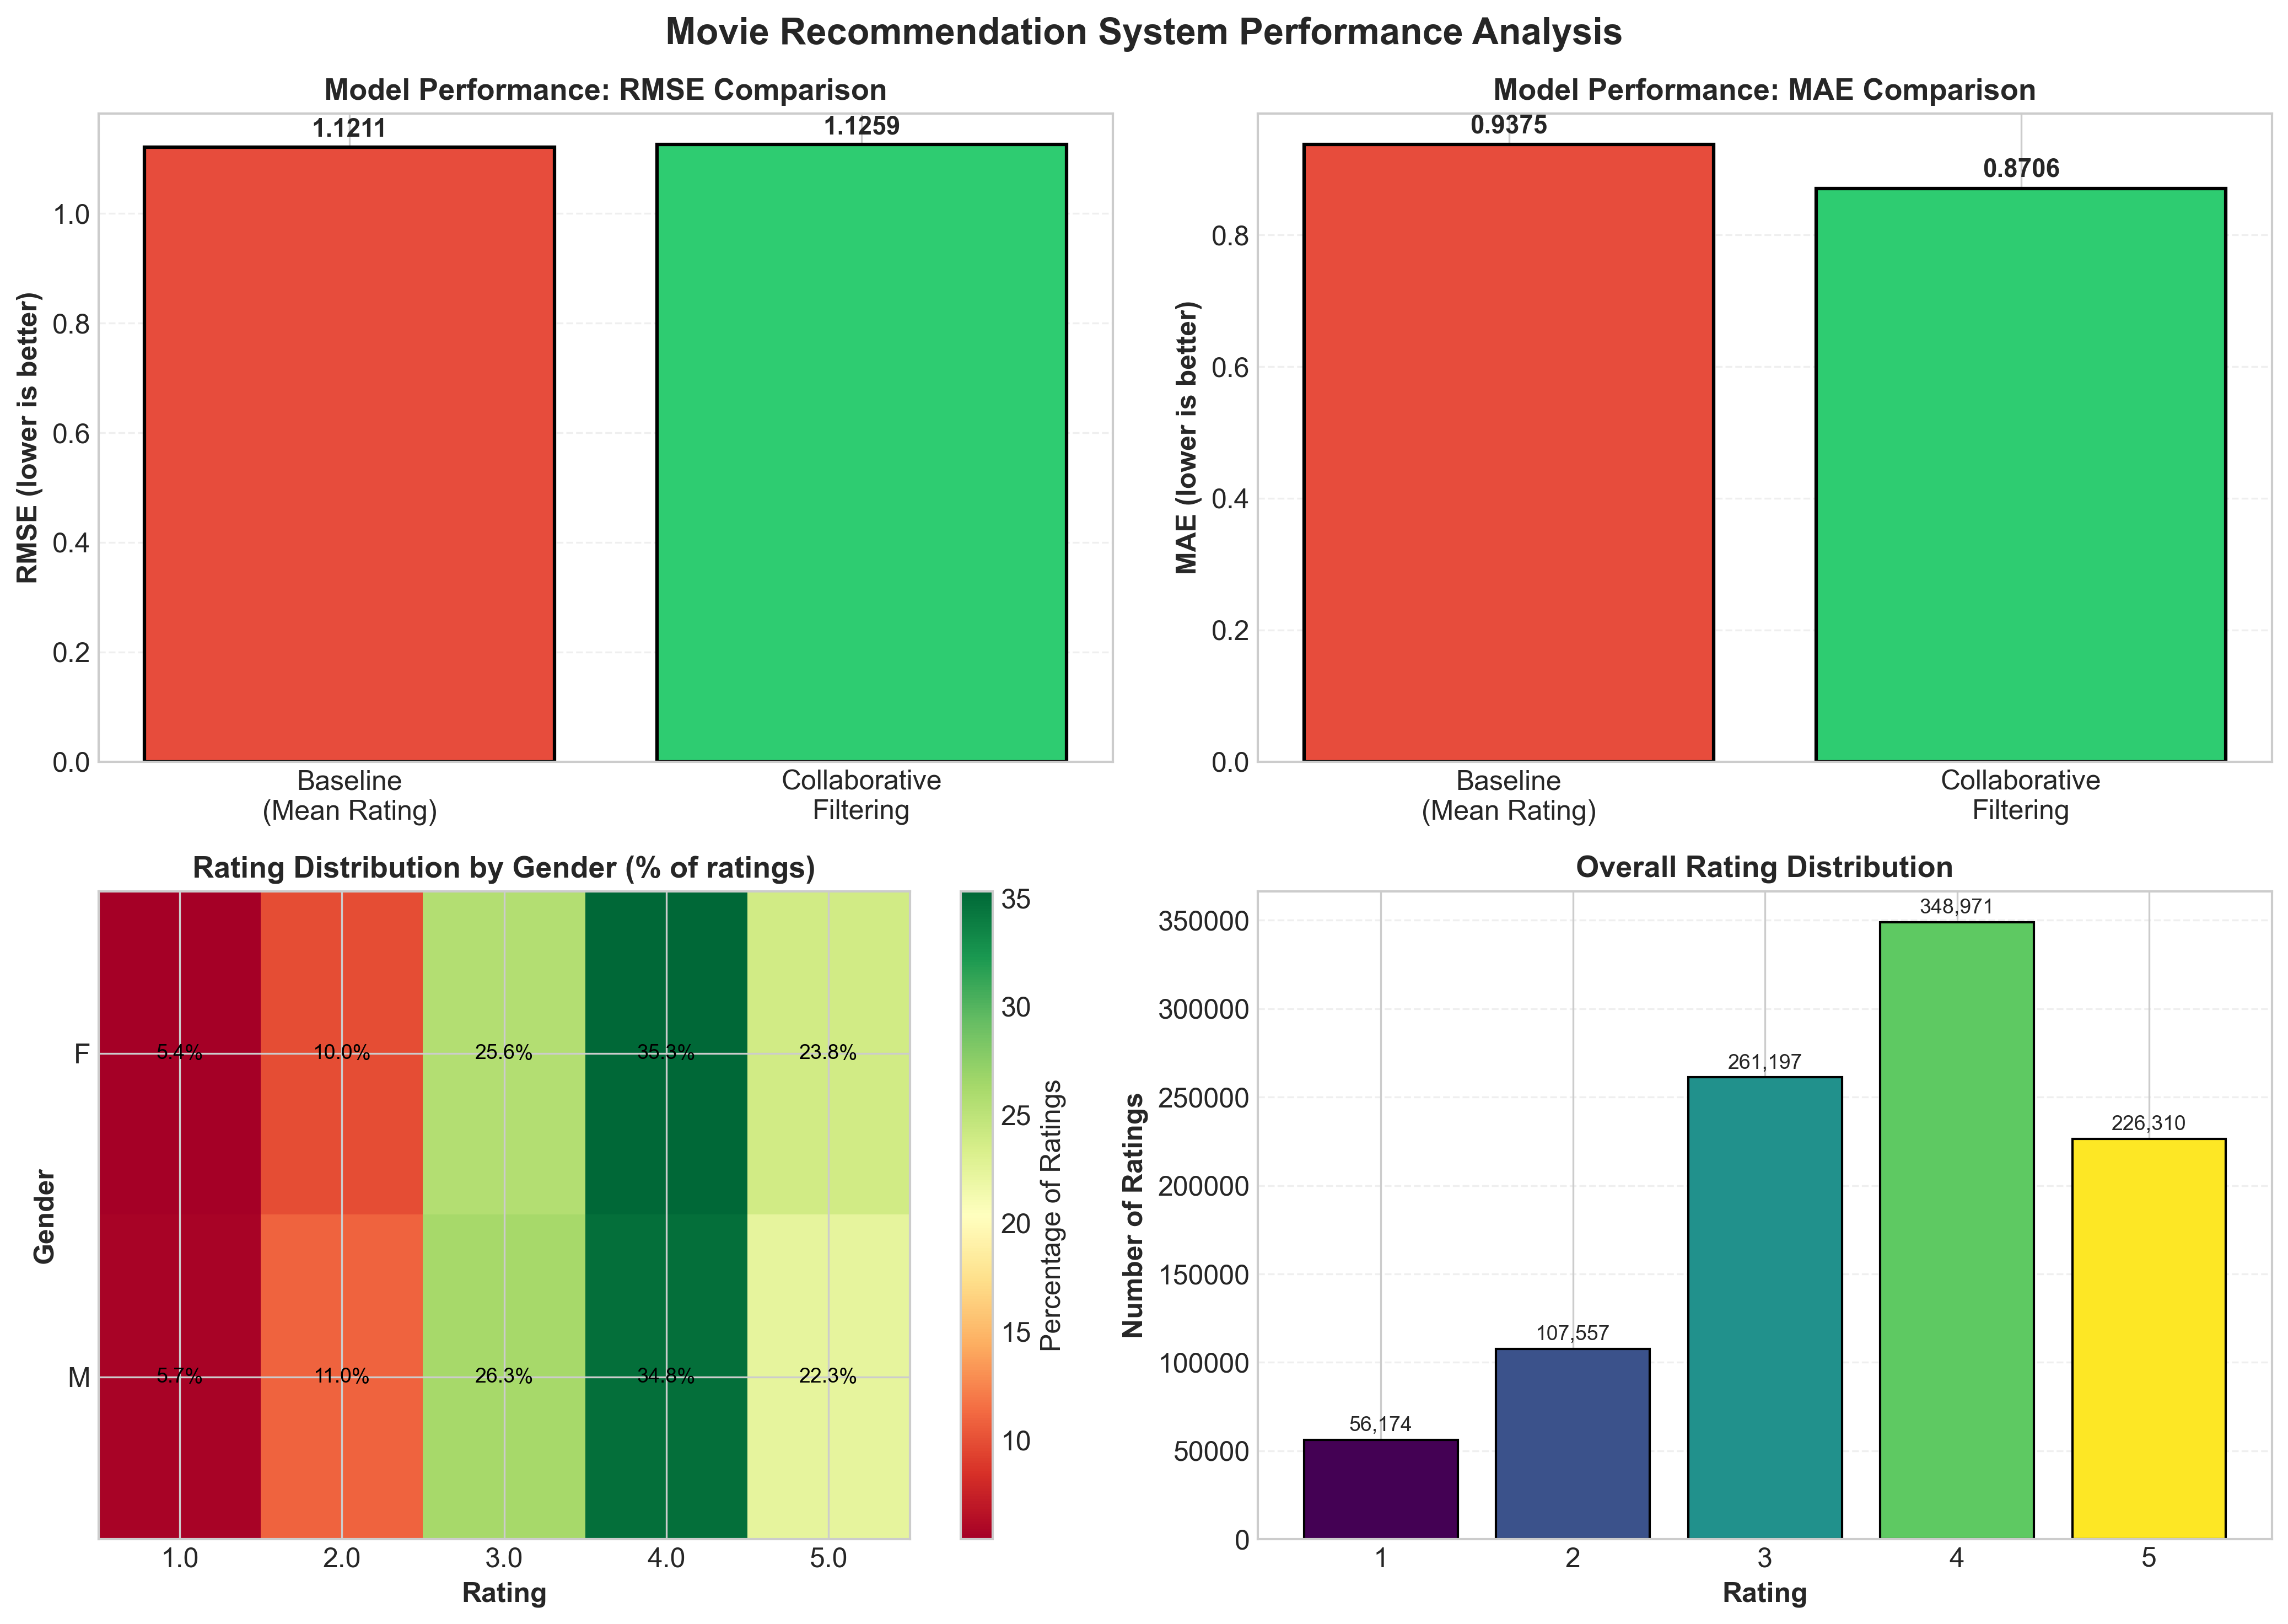

2026-05-08 10:05:18,760 - INFO - Publication-quality figure saved as 'recommendation_system_results.png'


In [52]:
# Publication-Quality Visualizations with Rationale

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for publication quality
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Movie Recommendation System Performance Analysis', fontsize=16, fontweight='bold')

# Plot 1: RMSE Comparison
models = ['Baseline\n(Mean Rating)', 'Collaborative\nFiltering']
rmse_values = [baseline_rmse, cf_rmse]
colors_rmse = ['#E74C3C', '#2ECC71']  # Red for baseline, green for collaborative filtering

bars = axes[0, 0].bar(models, rmse_values, color=colors_rmse, edgecolor='black', linewidth=1.5)
axes[0, 0].set_ylabel('RMSE (lower is better)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Model Performance: RMSE Comparison', fontsize=13, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, value in zip(bars, rmse_values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: MAE Comparison
mae_values = [baseline_mae, cf_mae]
bars2 = axes[0, 1].bar(models, mae_values, color=colors_rmse, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('MAE (lower is better)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Model Performance: MAE Comparison', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, value in zip(bars2, mae_values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 3: Rating Distribution by Gender (Heatmap)
gender_rating = pd.crosstab(df['gender'], df['rating'], normalize='index') * 100
im = axes[1, 0].imshow(gender_rating, cmap='RdYlGn', aspect='auto', interpolation='nearest')
axes[1, 0].set_xticks(range(len(gender_rating.columns)))
axes[1, 0].set_xticklabels(gender_rating.columns)
axes[1, 0].set_yticks(range(len(gender_rating.index)))
axes[1, 0].set_yticklabels(gender_rating.index)
axes[1, 0].set_xlabel('Rating', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Gender', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Rating Distribution by Gender (% of ratings)', fontsize=13, fontweight='bold')

# Add colorbar
plt.colorbar(im, ax=axes[1, 0], label='Percentage of Ratings')

# Add annotations to heatmap
for i in range(len(gender_rating.index)):
    for j in range(len(gender_rating.columns)):
        text = axes[1, 0].text(j, i, f'{gender_rating.iloc[i, j]:.1f}%',
                               ha="center", va="center", color="black", fontsize=9)

# Plot 4: Rating Frequency Distribution
rating_counts = df['rating'].value_counts().sort_index()
colors_ratings = plt.cm.viridis(np.linspace(0, 1, len(rating_counts)))
axes[1, 1].bar(rating_counts.index, rating_counts.values, color=colors_ratings, edgecolor='black')
axes[1, 1].set_xlabel('Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Ratings', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Overall Rating Distribution', fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Add count labels on bars
for i, (rating, count) in enumerate(rating_counts.items()):
    axes[1, 1].text(rating, count + 5000, f'{count:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('recommendation_system_results.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

logger.info("Publication-quality figure saved as 'recommendation_system_results.png'")

### Visualization Rationale
*Explain the decisions in your visualization process.*

**RMSE and MAE Comparisons:** I included two bar plots comparing the RMSE and the MAE between the baseline (mean) and the collaborative filtering model. These plots directly show how collaborative filtering measures up to the simple baseline, with RMSE being comparable and collaborative filtering outperforming the baseline in MAE. This gives the viewer a clear, immediate understanding of the model's value.

**Gender Distribution:** I included a heatmap showing the distribution of ratings in relation to gender. These plots allow us to identify demographic patterns in rating behavior, and consider how that may impact our predictions. From this plot, however, we can conclude that gender likely doesn't have a significant impact on rating, as the difference between male and female ratings in each bin never differs by more than 2%.

**Rating Distribution:** I included a bar plot that demonstrates the overall distribution of ratings for movie reviews. This was included to allow the viewer to visualize the proportion of rating scores, as skew or an uneven distribution in our data could impact the model's predictive power for certain underrepresented ratings. This plot is skewed left, with 4 being the most common rating (~350k), followed by 3, 5, 2, and then 1. There is a significant difference in quantity of ratings between the most and least common, with 4 having nearly 350,000 ratings while 1 has just a little over 50,000. This chart is important because it gives the user more perspective to understand that the model was trained on significantly more of some values than others, and for that reason it may predict ratings like 4 with high accuracy, and ratings like 1 with low accuracy.